In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc,
                              precision_recall_curve, average_precision_score)
import re
import time



In [2]:
# 1. 載入資料
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

In [3]:
# 2. 加標籤 & 合併
df_fake["label"] = 0
df_true["label"] = 1
df = pd.concat([df_fake, df_true]).sample(frac=1, random_state=42).reset_index(drop=True)

In [4]:
# 3. 用標題 + 內文一起當特徵
df["content"] = df["title"] + " " + df["text"]

In [5]:
# 新增文字特徵欄位 
df["text_len"]       = df["text"].str.len()                          # 字元數
df["word_count"]     = df["text"].str.split().str.len()              # 詞數
df["title_len"]      = df["title"].str.len()                         # 標題長度
df["exclaim_count"]  = df["text"].str.count("!")                     # 驚嘆號數
df["question_count"] = df["text"].str.count(r"\?")                   # 問號數
df["upper_ratio"]    = df["text"].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)                                                                     # 大寫字母比例

label_map = {0: "Fake", 1: "Real"}
df["label_name"] = df["label"].map(label_map)

# 印出基本統計 
print("📋 資料集基本資訊")
print(f"總筆數：{len(df):,}")
print(f"假新聞：{(df.label == 0).sum():,} 筆")
print(f"真新聞：{(df.label == 1).sum():,} 筆")
print(f"缺值數：{df[['title','text']].isnull().sum().to_dict()}")
print()
print(df.groupby("label_name")[["text_len","word_count","title_len",
                                "exclaim_count","upper_ratio"]].mean().round(2))

📋 資料集基本資訊
總筆數：44,898
假新聞：23,481 筆
真新聞：21,417 筆
缺值數：{'title': 0, 'text': 0}

            text_len  word_count  title_len  exclaim_count  upper_ratio
label_name                                                             
Fake         2547.40      423.20      94.20           0.72         0.05
Real         2383.28      385.64      64.67           0.06         0.04


C:\Users\Lee\AppData\Local\Temp\ipykernel_74076\1094485665.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="label_name", y="word_count",


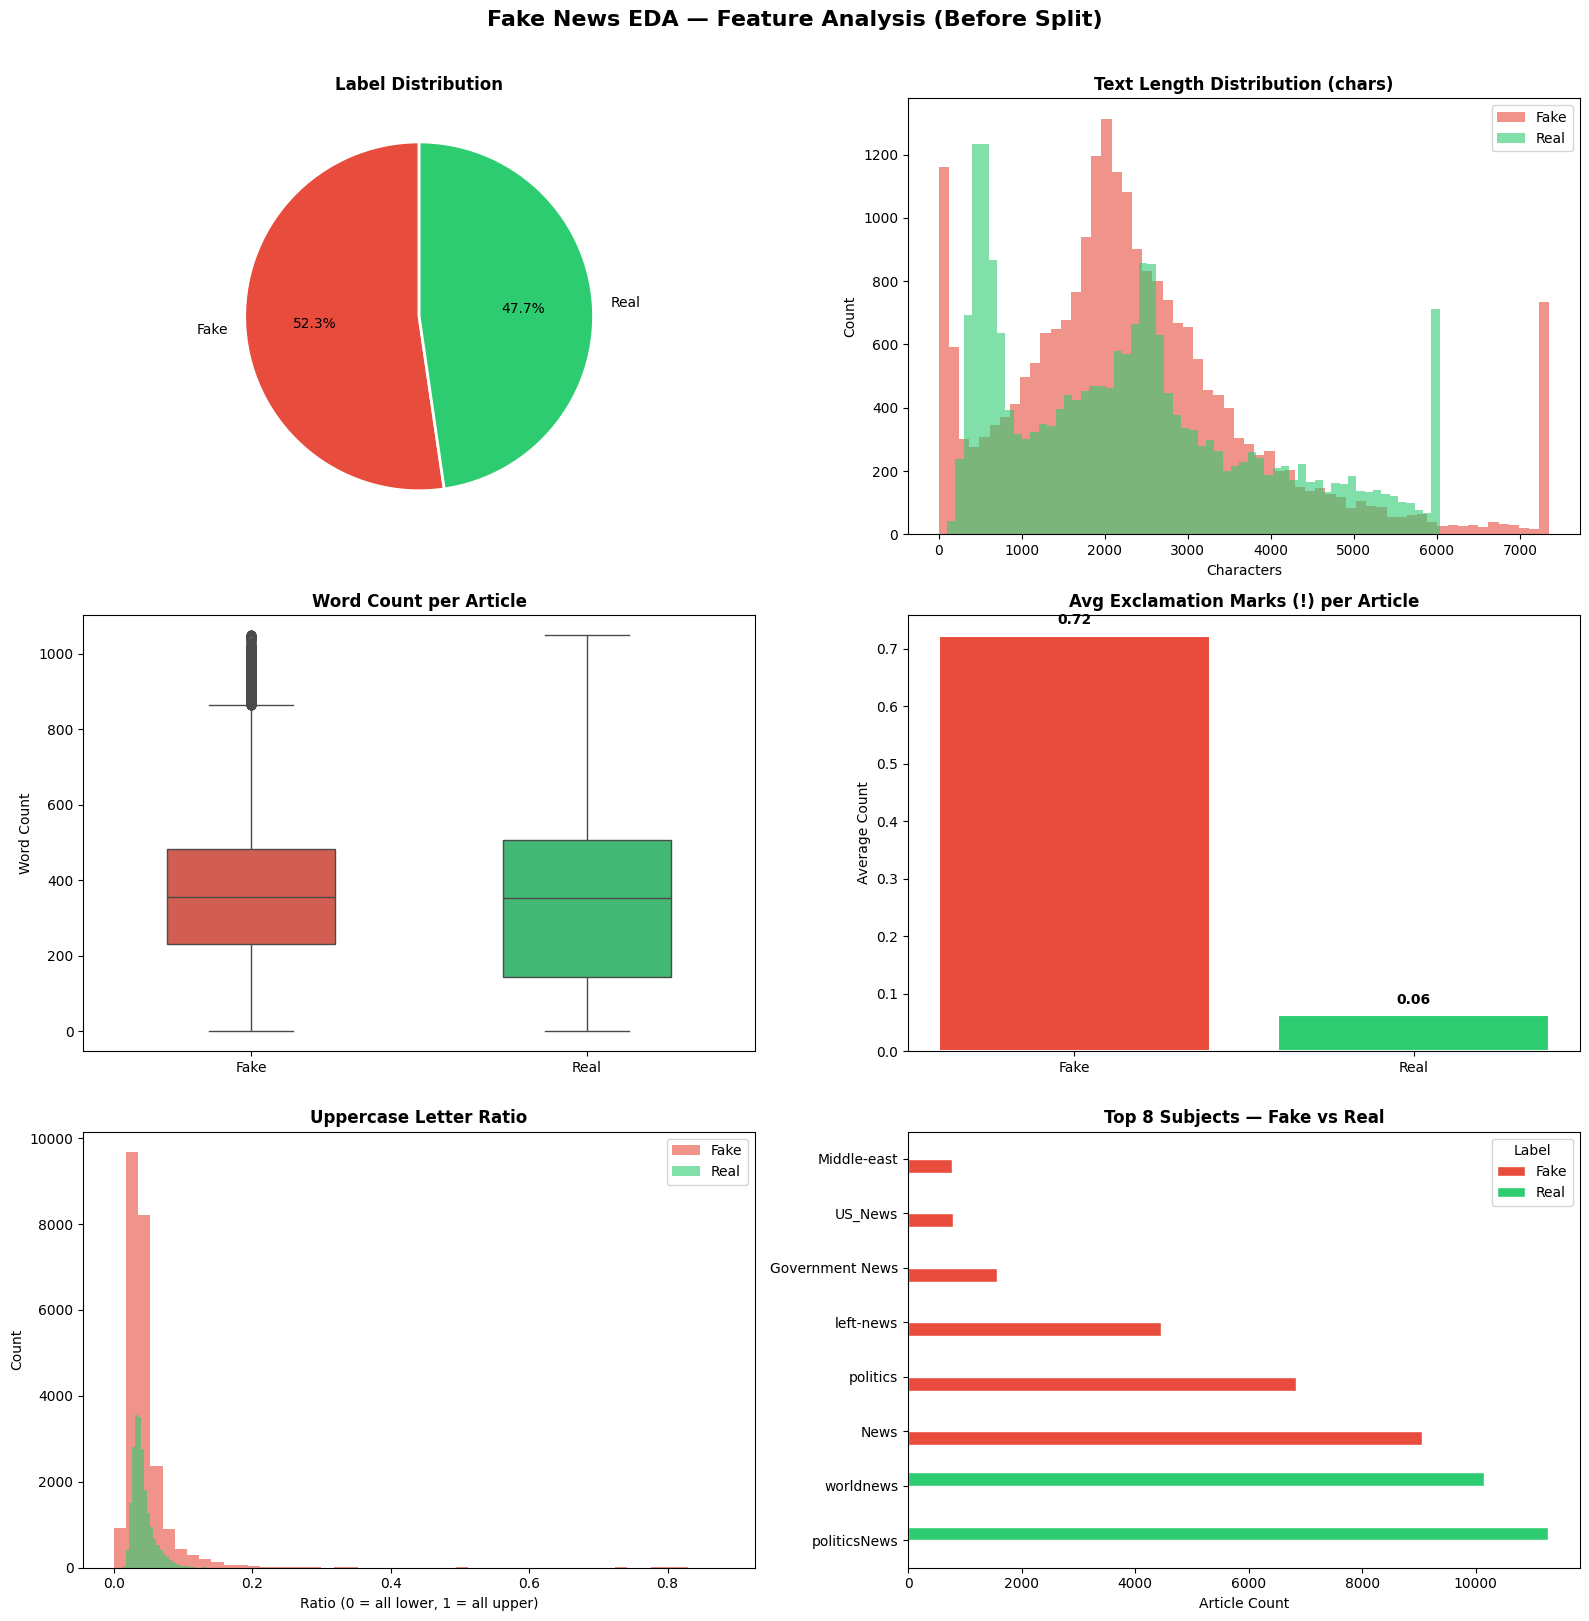

In [6]:
# 畫圖：3 列 × 2 欄，共 6 張子圖
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle("Fake News EDA — Feature Analysis (Before Split)",
             fontsize=16, fontweight="bold", y=1.01)

palette = {"Fake": "#e74c3c", "Real": "#2ecc71"}

# 1. 類別分布（圓餅圖）
counts = df["label_name"].value_counts()
axes[0, 0].pie(counts, labels=counts.index, autopct="%1.1f%%",
               colors=[palette["Fake"], palette["Real"]],
               startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0, 0].set_title("Label Distribution", fontweight="bold")

# 2. 文章內文長度分布
for lbl in ["Fake", "Real"]:
    subset = df[df["label_name"] == lbl]["text_len"]
    axes[0, 1].hist(subset.clip(upper=subset.quantile(0.97)),
                    bins=60, alpha=0.6, label=lbl, color=palette[lbl])
axes[0, 1].set_title("Text Length Distribution (chars)", fontweight="bold")
axes[0, 1].set_xlabel("Characters")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# 3. 詞數 Box Plot
df_plot = df[df["word_count"] < df["word_count"].quantile(0.97)]
sns.boxplot(data=df_plot, x="label_name", y="word_count",
            palette=palette, ax=axes[1, 0], width=0.5)
axes[1, 0].set_title("Word Count per Article", fontweight="bold")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Word Count")

# 4. 驚嘆號使用次數
exclaim_mean = df.groupby("label_name")["exclaim_count"].mean()
bars = axes[1, 1].bar(exclaim_mean.index, exclaim_mean.values,
                      color=[palette[l] for l in exclaim_mean.index],
                      edgecolor="white", linewidth=1.5)
axes[1, 1].set_title("Avg Exclamation Marks (!) per Article", fontweight="bold")
axes[1, 1].set_ylabel("Average Count")
for bar, val in zip(bars, exclaim_mean.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{val:.2f}", ha="center", fontweight="bold")

# 5. 大寫字母比例分布
for lbl in ["Fake", "Real"]:
    subset = df[df["label_name"] == lbl]["upper_ratio"]
    axes[2, 0].hist(subset, bins=50, alpha=0.6, label=lbl, color=palette[lbl])
axes[2, 0].set_title("Uppercase Letter Ratio", fontweight="bold")
axes[2, 0].set_xlabel("Ratio (0 = all lower, 1 = all upper)")
axes[2, 0].set_ylabel("Count")
axes[2, 0].legend()

# 6. 主題類別分布（Top 8 主題）
subject_counts = df.groupby(["subject", "label_name"]).size().unstack(fill_value=0)
subject_counts = subject_counts.loc[subject_counts.sum(axis=1).nlargest(8).index]
subject_counts.plot(kind="barh", ax=axes[2, 1],
                    color=[palette["Fake"], palette["Real"]],
                    edgecolor="white")
axes[2, 1].set_title("Top 8 Subjects — Fake vs Real", fontweight="bold")
axes[2, 1].set_xlabel("Article Count")
axes[2, 1].set_ylabel("")
axes[2, 1].legend(title="Label")

plt.tight_layout()
plt.savefig("eda_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# 4. 切訓練/測試集
X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
# 5. 訓練 Logistic Regression + LinearSVC

raw_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LinearSVC (SVM)":     CalibratedClassifierCV(LinearSVC(max_iter=2000)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, classifier in raw_models.items():
    oof_pred = np.zeros(len(X_train), dtype=int)
    oof_prob = np.zeros(len(X_train), dtype=float)

    fold_start = time.time()
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        pipe = Pipeline([
            ("tfidf", TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2))),
            ("clf", clone(classifier)),
        ])

        pipe.fit(X_tr, y_tr)
        oof_pred[val_idx] = pipe.predict(X_val)
        oof_prob[val_idx] = pipe.predict_proba(X_val)[:, 1]

    print(f"{name} OOF")
    print(classification_report(y_train, oof_pred, target_names=["Fake", "Real"]))
    print(f"OOF Accuracy: {accuracy_score(y_train, oof_pred):.4f}")
    print()

    t0 = time.time()
    final_model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2))),
        ("clf", clone(classifier)),
    ])
    final_model.fit(X_train, y_train)

    y_pred = final_model.predict(X_test)
    y_prob = final_model.predict_proba(X_test)[:, 1]
    elapsed = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    print(f"{name:25s} | Acc: {acc:.4f} | Time: {elapsed:.2f}s")

    results[name] = {
        "pred": y_pred,
        "prob": y_prob,
        "model": final_model,
        "oof_pred": oof_pred,
        "oof_prob": oof_prob,
    }

Logistic Regression OOF
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99     18785
        Real       0.99      0.99      0.99     17133

    accuracy                           0.99     35918
   macro avg       0.99      0.99      0.99     35918
weighted avg       0.99      0.99      0.99     35918

OOF Accuracy: 0.9886

Logistic Regression       | Acc: 0.9890 | Time: 32.20s
LinearSVC (SVM) OOF
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00     18785
        Real       0.99      0.99      0.99     17133

    accuracy                           0.99     35918
   macro avg       0.99      0.99      0.99     35918
weighted avg       0.99      0.99      0.99     35918

OOF Accuracy: 0.9948

LinearSVC (SVM)           | Acc: 0.9952 | Time: 35.11s


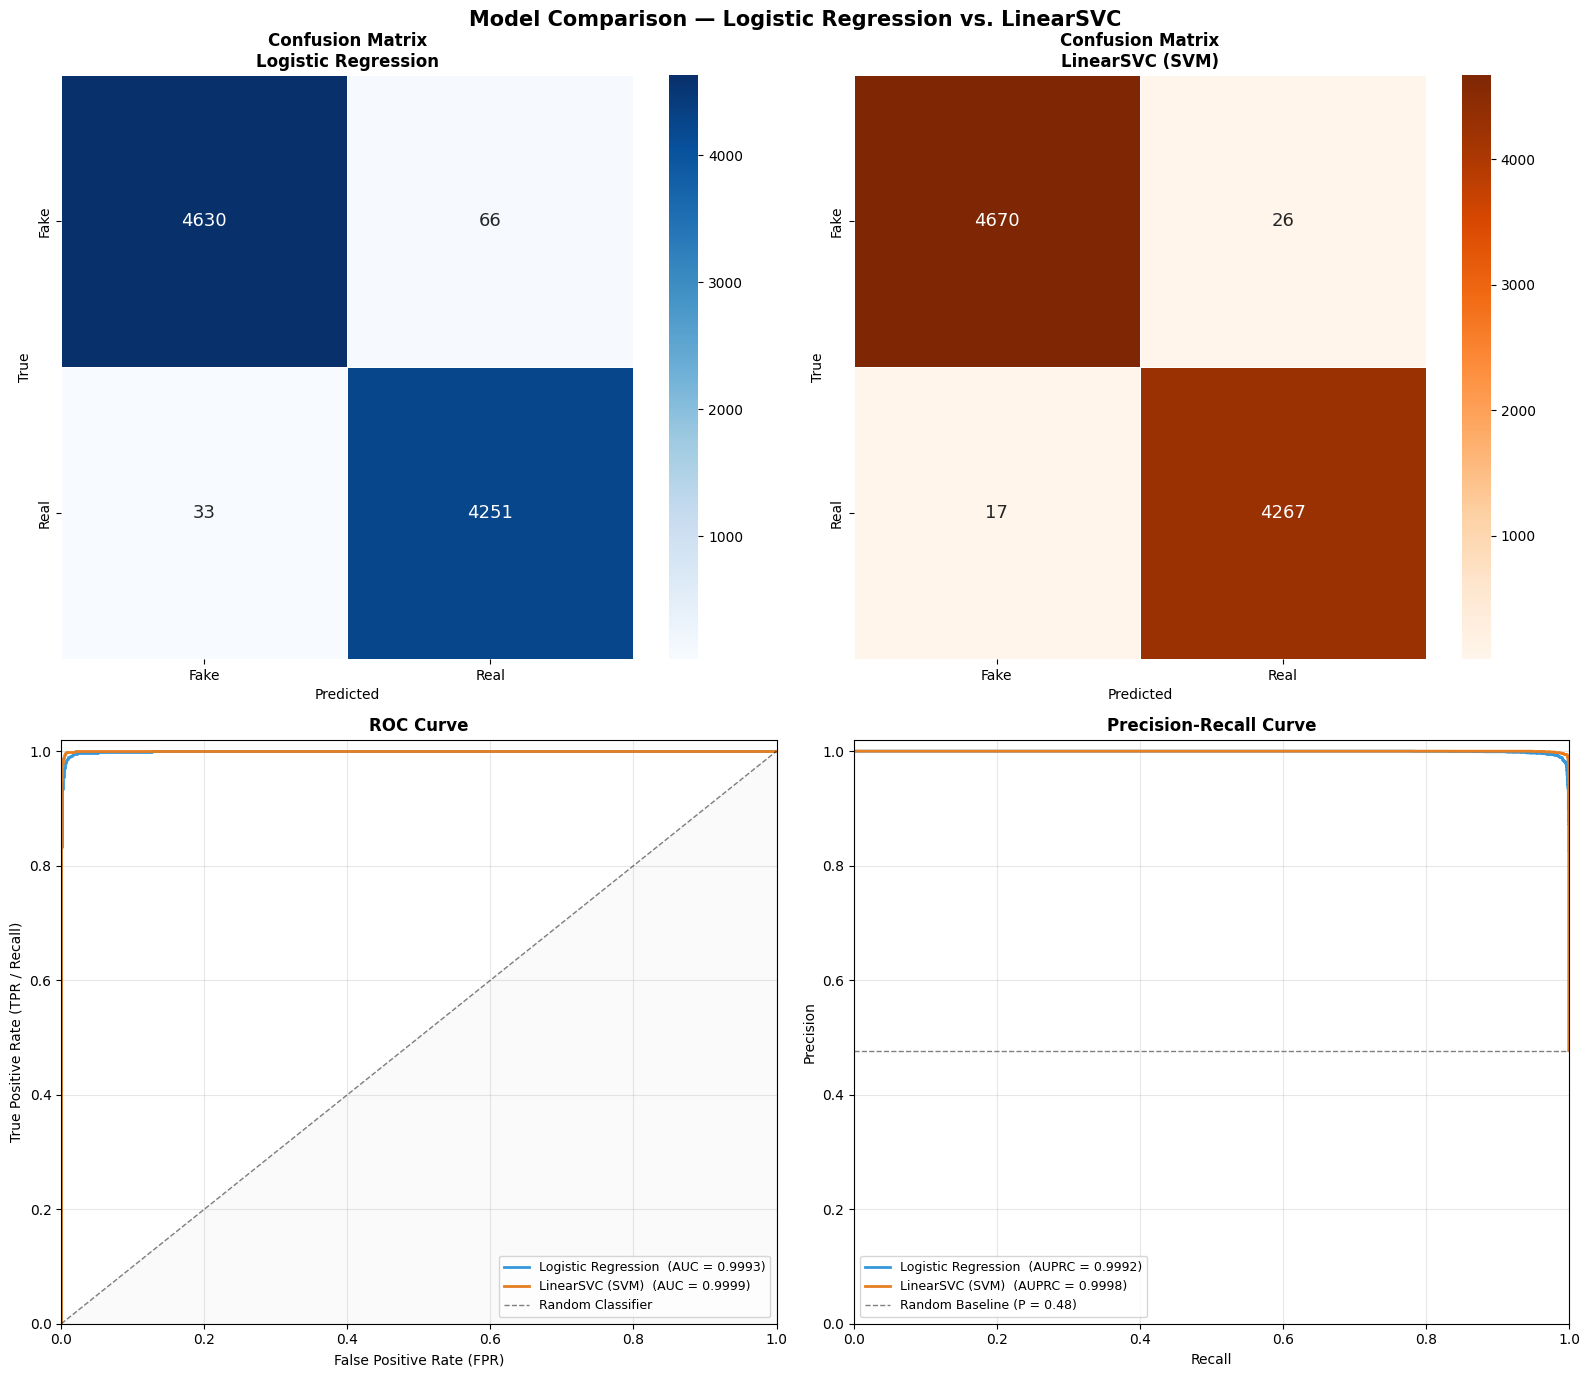

In [ ]:
# 6. 繪製 Confusion Matrix、ROC Curve、PR Curve
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Model Comparison — Logistic Regression vs. LinearSVC",
             fontsize=15, fontweight="bold")

colors = {"Logistic Regression": "#3498db", "LinearSVC (SVM)": "#e67e22"}
cm_labels = ["Fake", "Real"]
cmap_list = {"Logistic Regression": "Blues", "LinearSVC (SVM)": "Oranges"}

# 左上 & 右上：各自一格 Confusion Matrix
cm_axes = [axes[0, 0], axes[0, 1]]
for ax, (name, res) in zip(cm_axes, results.items()):
    cm = confusion_matrix(y_test, res["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap_list[name],
                xticklabels=cm_labels, yticklabels=cm_labels,
                ax=ax, linewidths=0.5, annot_kws={"size": 13})
    ax.set_title(f"Confusion Matrix\n{name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# 左下：ROC Curve
ax_roc = axes[1, 0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["prob"])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=colors[name], lw=2,
                label=f"{name}  (AUC = {roc_auc:.4f})")

ax_roc.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random Classifier")
ax_roc.fill_between([0, 1], [0, 1], alpha=0.04, color="gray")
ax_roc.set_title("ROC Curve", fontweight="bold")
ax_roc.set_xlabel("False Positive Rate (FPR)")
ax_roc.set_ylabel("True Positive Rate (TPR / Recall)")
ax_roc.legend(loc="lower right", fontsize=9)
ax_roc.set_xlim([0, 1])
ax_roc.set_ylim([0, 1.02])
ax_roc.grid(alpha=0.3)

# 右下：PR Curve
ax_pr = axes[1, 1]
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["prob"])
    ap = average_precision_score(y_test, res["prob"])
    ax_pr.plot(rec, prec, color=colors[name], lw=2,
               label=f"{name}  (AUPRC = {ap:.4f})")

baseline = y_test.mean()
ax_pr.axhline(baseline, color="gray", lw=1, ls="--",
              label=f"Random Baseline (P = {baseline:.2f})")
ax_pr.set_title("Precision-Recall Curve", fontweight="bold")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.legend(loc="lower left", fontsize=9)
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.02])
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()